## XGBoost

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import pearsonr, linregress


In [2]:
filtered_df = pd.read_csv('yield_pani_seed_count.csv')
filtered_df

,Plot_Pedigree,Plot,Pedigree,Range,Row,Pass,Rep,Yld_ton_ha,GT_Pan_Count,DG_Pan_Count,...,Lab_Pan_Size_cm2,MK_Pan_Size_cm2,Predict_Pan_Size_Pixel,Mach_Seed_Count,Pan_Seed_Count,Reg_Seed_Count,Spr_Seed_Count,Microscope_Area_mm2,DG_Seed_Area_mm2,SKCS_Seed_dia_mm
0,2005-SC964,2005,SC964,2,6,2,1,3.941257,166,129,...,119.284937,71.477387,15499.42034,1839,1276,2041,2006.0,9.947,11.692672,2.410843
1,2009-RTx430BL,2009,RTx430BL,2,10,3,1,4.333421,139,96,...,131.744064,66.349287,14985.00490,882,742,1309,1019.0,12.038,7.009835,3.050454
2,2013-Tx7000,2013,Tx7000,2,14,4,1,5.192731,168,151,...,217.827004,91.675497,15368.33830,2275,1573,1898,2402.0,11.847,16.766636,3.066632
3,2017-RLBK1,2017,RLBK1,2,18,5,1,1.378816,102,103,...,128.253696,45.303214,11945.51458,696,485,1273,727.0,10.234,8.325976,2.603187
4,2021-SC326-6,2021,SC326-6,2,22,6,1,3.612592,139,116,...,301.718209,140.481508,11716.55753,2868,1283,1869,2844.0,10.059,14.686166,2.493731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,7057-SC348,7057,SC348,7,58,15,3,4.691004,162,143,...,290.669999,132.968718,14443.86043,1228,893,1185,1387.0,13.822,18.901944,3.470536
104,7061-2219-3,7061,2219-3,7,62,16,3,2.665269,142,129,...,138.694163,79.016643,21268.46541,1406,1143,1863,1341.0,11.228,10.861323,2.820719
105,7065-SN72_PINK_KAFIR,7065,SN72_PINK_KAFIR,7,66,17,3,4.819019,162,143,...,418.212315,132.810339,21307.71462,1562,1152,1380,1611.0,9.038,9.194070,2.654018
106,7069-2290-19,7069,2290-19,7,70,18,3,5.339355,160,142,...,227.874814,141.366547,14740.30994,1483,1492,1532,1572.0,11.696,12.537695,3.012687


In [3]:
filtered_df = filtered_df.dropna()
filtered_df.columns

Index(['Plot_Pedigree', 'Plot', 'Pedigree', 'Range', 'Row', 'Pass', 'Rep',
       'Yld_ton_ha', 'GT_Pan_Count', 'DG_Pan_Count', 'GT_Pan_Size_cm2',
       'B_Box_Pan_Size_cm2', 'Lab_Pan_Size_cm2', 'MK_Pan_Size_cm2',
       'Predict_Pan_Size_Pixel', 'Mach_Seed_Count', 'Pan_Seed_Count',
       'Reg_Seed_Count', 'Spr_Seed_Count', 'Microscope_Area_mm2',
       'DG_Seed_Area_mm2', 'SKCS_Seed_dia_mm'],
      dtype='str')

In [4]:
X = filtered_df[['MK_Pan_Size_cm2', 'Pan_Seed_Count', 'DG_Pan_Count', 'DG_Seed_Area_mm2']]
y = filtered_df[['Yld_ton_ha']]
X

,MK_Pan_Size_cm2,Pan_Seed_Count,DG_Pan_Count,DG_Seed_Area_mm2
0,71.477387,1276,129,11.692672
1,66.349287,742,96,7.009835
2,91.675497,1573,151,16.766636
3,45.303214,485,103,8.325976
4,140.481508,1283,116,14.686166
...,...,...,...,...
103,132.968718,893,143,18.901944
104,79.016643,1143,129,10.861323
105,132.810339,1152,143,9.194070
106,141.366547,1492,142,12.537695


In [5]:
y

,Yld_ton_ha
0,3.941257
1,4.333421
2,5.192731
3,1.378816
4,3.612592
...,...
103,4.691004
104,2.665269
105,4.819019
106,5.339355


# XGBoost

In [7]:
np.random.seed(5141)
# ── Data loading ──────────────────────────────────────────────────────────────
# Encode any categorical columns
non_numeric_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in non_numeric_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# ── Training loop ─────────────────────────────────────────────────────────────
# best_mse      = -float('inf')
best_mse      = float('inf')
best_model    = None
best_scaler_X = None
best_scaler_y = None
best_x_test   = None
best_y_test   = None
best_seed     = None
mse_list      = []

for i in range(10):
    random_seed = np.random.randint(10000)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed
    )

    # Scale features and target
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train).ravel()

    # ── Model definition ──────────────────────────────────────────────────────
    hgb_model = HistGradientBoostingRegressor(
        max_iter=300,              # number of boosting rounds
        max_depth=4,               # maximum tree depth per round
        learning_rate=0.05,        # shrinkage rate
        l2_regularization=1.0,    # L2 regularization
        early_stopping=True,       # stop when validation loss stalls
        validation_fraction=0.1,   # fraction of train data used for validation
        n_iter_no_change=20,       # patience for early stopping
        random_state=random_seed
    )

    hgb_model.fit(X_train_scaled, y_train_scaled)

    # Predict and inverse-transform
    y_pred_scaled = hgb_model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

    if mse < best_mse:
        best_mse      = mse
        best_model    = hgb_model
        best_scaler_X = scaler_X
        best_scaler_y = scaler_y
        best_x_test   = X_test
        best_y_test   = y_test
        best_seed     = random_seed

print(f"Best random seed : {best_seed}")
print(f"All MSEs         : {mse_list}")
print(f"Best MSE         : {best_mse:.4f}")

Best random seed : 4194
All MSEs         : [0.7108446437267781, 0.6302015341324161, 1.1355446625486232, 0.8389683016949728, 0.47784813145994515, 0.43092361234017157, 0.7021427325477785, 0.48178075650416435, 0.6820901175438157, 0.49186089222770646]
Best MSE         : 0.4309


In [10]:
# ── Best-model predictions ────────────────────────────────────────────────────
X_test_scaled_best = best_scaler_X.transform(best_x_test)
test_pred_scaled   = best_model.predict(X_test_scaled_best)
test_predictions   = best_scaler_y.inverse_transform(
    test_pred_scaled.reshape(-1, 1)
).ravel()

actual = best_y_test.values.ravel()

# ── Results DataFrame ─────────────────────────────────────────────────────────
# results_df = pd.DataFrame({
#     'Actual_values':    actual,
#     'Predicted_values': test_predictions,
#     'MSE':              (actual - test_predictions) ** 2
# })

df = pd.DataFrame({
    'Actual_values':    actual,
    'Predicted_values': test_predictions
    
})
print(df.head())

   Actual_values  Predicted_values
0       4.228524          4.149139
1       2.396743          2.381386
2       1.179194          2.226552
3       2.253293          3.000753
4       4.015143          4.426895


In [11]:
df

,Actual_values,Predicted_values
0,4.228524,4.149139
1,2.396743,2.381386
2,1.179194,2.226552
3,2.253293,3.000753
4,4.015143,4.426895
5,4.738224,3.954155
6,3.237142,3.843007
7,3.788660,3.954155
8,5.109309,4.083361
9,1.378816,2.182092


In [14]:
import os
csv_path = os.path.join(
    os.getcwd(),
    "xgboost_prediction.csv"
)

df.to_csv(csv_path, index=False)

print(f"CSV saved successfully at: {csv_path}")

CSV saved successfully at: c:\GitHub_AI_Workshop\codes\5_yield_prediction\2_ml_models\xgboost_prediction.csv


     Actual  Predicted  Plot_Pedigree
0  3.941257   3.487525     2005-SC964
1  4.333421   2.182092  2009-RTx430BL
2  5.192731   4.405367    2013-Tx7000
3  1.378816   2.182092     2017-RLBK1
4  3.612592   3.123401   2021-SC326-6


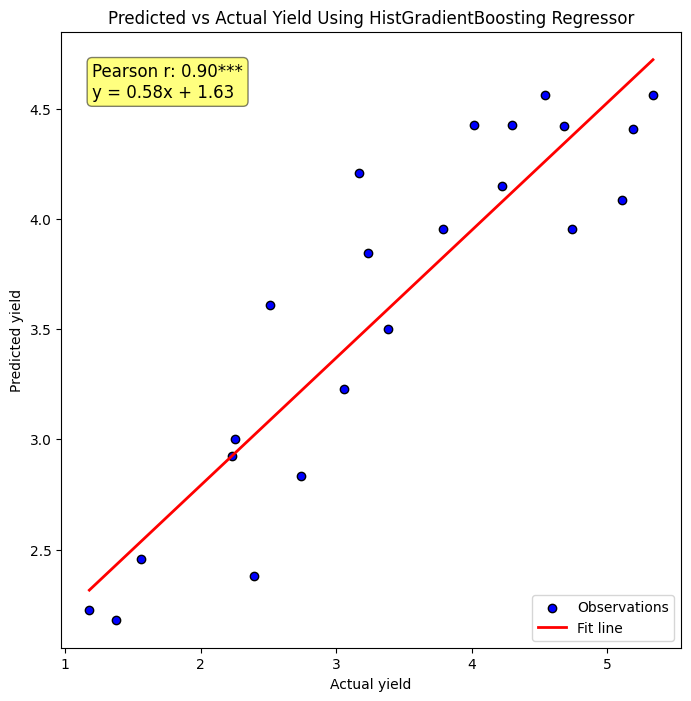

In [15]:
# ── Final predictions on entire dataset ───────────────────────────────────────
X_all_scaled      = best_scaler_X.transform(X)
final_pred_scaled = best_model.predict(X_all_scaled)
final_predictions = best_scaler_y.inverse_transform(
    final_pred_scaled.reshape(-1, 1)
).ravel()

final_df = pd.DataFrame({
    'Actual':        y.values.ravel(),
    'Predicted':     final_predictions,
    'Plot_Pedigree': filtered_df['Plot_Pedigree']
})
print(final_df.head())

# ── Plot ──────────────────────────────────────────────────────────────────────
correlation, p_value = pearsonr(actual, test_predictions)

if p_value < 0.001:
    sig_label = '***'
elif p_value < 0.01:
    sig_label = '**'
elif p_value < 0.05:
    sig_label = '*'
else:
    sig_label = ''

slope, intercept, _, _, _ = linregress(actual, test_predictions)
x_line = np.linspace(actual.min(), actual.max(), 200)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 8))
plt.scatter(actual, test_predictions, color='blue', edgecolor='k',
            label='Observations')
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Fit line')

plt.xlabel('Actual yield')
plt.ylabel('Predicted yield')
plt.title('Predicted vs Actual Yield Using HistGradientBoosting Regressor')
plt.legend()

text_str = (f'Pearson r: {correlation:.2f}{sig_label}\n'
            f'y = {slope:.2f}x + {intercept:.2f}')
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow',
                   edgecolor='black', alpha=0.5))

plt.axis('tight')
plt.savefig('HGB_actual_vs_predicted_plot.png', dpi=300)
plt.show()